In [4]:
pip install selenium

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------------- -------------- 6.0/9.5 MB 35.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 25.9 MB/s  0:00:00

   ---------------------------------------- 0/8 [sortedcontainers]
   ----- ---------------------------------- 1/8 [wsproto]
   ----- ---------------------------------- 1/8 [wsproto]
   ----- ---------------------------------- 1/8 [wsproto]
   ---------- ----------------------------- 2/8 [sniffio]
   ---------- ----------------------------- 2/8 [sniffio]
   ---------- ----------------------------- 2/8 [sniffio]
   --------------- ------------------------ 3/8 [pysocks]
   -------------------- ------------------- 4/8 [outcome]
   -------------------- ------------------- 4/8 [outcome]
   ------------------------- -------------- 5/8 [trio]
   ------------------------- -------------- 5/8 [trio]
  

In [5]:
from selenium import webdriver

In [6]:
import os

In [7]:
print(os.getcwd())

c:\Users\user\Desktop\self_study


In [13]:
driver = webdriver.Chrome()

In [14]:
driver.implicitly_wait(3)

In [15]:
driver.get("https://www.livesport.com/kr/team/manchester-united/ppjDR086/")

In [16]:
pip install bs4

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [17]:
from bs4 import BeautifulSoup

In [18]:
page = driver.page_source

In [19]:
bs_obj = BeautifulSoup(page, "html.parser")
bs_obj

<html lang="ko"><head>
<meta charset="utf-8"/>
<title>Livesport: 맨체스터 유나이티드 - 결과, 일정, 에버턴 vs 맨체스터 유나이티드 live</title>
<script async="" src="https://www.googletagmanager.com/gtag/destination?id=AW-999393459&amp;cx=c&amp;gtm=4e62i1h1" type="text/javascript"></script><script async="" src="https://www.googletagmanager.com/gtag/js?id=G-2ML68HVXTQ&amp;cx=c&amp;gtm=4e62i1h1" type="text/javascript"></script><script async="" src="https://unpkg.com/web-vitals@5.0.1/dist/web-vitals.iife.js" type="text/javascript"></script><script async="" src="//www.googletagmanager.com/gtm.js?id=GTM-PWJ3NQ"></script><script charset="UTF-8" data-document-language="true" data-domain-script="be4cd6ae-414e-4784-a9f8-29c9eb574714" defer="" src="https://cdn.cookielaw.org/scripttemplates/otSDKStub.js" type="text/javascript">
</script>
<link crossorigin="" href="https://713.ds.lsapp.eu/pq_graphql" rel="preconnect"/>
<link crossorigin="" href="https://500.flashscore.ninja" rel="preconnect"/>
<link as="font" crossorigin=""

In [21]:
win = bs_obj.find_all("button", {"class":"wcl-badgeform_AKaAR wcl-win_8x-jp wcl-clickable_dpoK5 formIcon__lastMatches"})
win

[<button class="wcl-badgeform_AKaAR wcl-win_8x-jp wcl-clickable_dpoK5 formIcon__lastMatches" data-testid="wcl-badgeForm-win" title="승"><span class="wcl-scores-simple-text-01_-OvnR wcl-scores_Na715" data-testid="wcl-scores-simple-text-01">승</span></button>,
 <button class="wcl-badgeform_AKaAR wcl-win_8x-jp wcl-clickable_dpoK5 formIcon__lastMatches" data-testid="wcl-badgeForm-win" title="승"><span class="wcl-scores-simple-text-01_-OvnR wcl-scores_Na715" data-testid="wcl-scores-simple-text-01">승</span></button>,
 <button class="wcl-badgeform_AKaAR wcl-win_8x-jp wcl-clickable_dpoK5 formIcon__lastMatches" data-testid="wcl-badgeForm-win" title="승"><span class="wcl-scores-simple-text-01_-OvnR wcl-scores_Na715" data-testid="wcl-scores-simple-text-01">승</span></button>,
 <button class="wcl-badgeform_AKaAR wcl-win_8x-jp wcl-clickable_dpoK5 formIcon__lastMatches" data-testid="wcl-badgeForm-win" title="승"><span class="wcl-scores-simple-text-01_-OvnR wcl-scores_Na715" data-testid="wcl-scores-simple-

In [2]:
from bs4 import BeautifulSoup
from urllib.request import urlopen

In [ ]:
endpoint = "https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do"
serviceKey = ""
startmonth = "201901"
endmonth = "202512"
region_list = ["510003","510007","510023"]
stable_id="A_2024_00549"
data_list = []

for region in region_list:
    url = endpoint + "?" + \
    "Key=" + serviceKey + \
    "&" + "STATBL_ID=" + stable_id + \
    "&" + "DTACYCLE_CD=MM" + \
    "&" + "ITM_ID=100001" + \
    "&" + "CLS_ID=" + region + \
    "&" + "START_WRTTIME=" + startmonth +\
    "&" + "END_WRTTIME=" + endmonth 

    html = urlopen(url)
    bs_obj = BeautifulSoup(html, "html.parser")
    print(bs_obj)


    # 2. find_all() 함수로 모든 <row> 태그를 찾아서 반복
    for row in bs_obj.find_all('row'):
        # 태그 이름으로 바로 접근하여 텍스트(.text) 추출
        region = row.find('cls_nm').text
        date = row.find('wrttime_idtfr_id').text
        count = int(row.find('dta_val').text)  # 정수형으로 변환
        
        # 리스트 형태로 리스트에 추가 (원하시면 [region, date, count] 형태의 리스트로 넣으셔도 됩니다)
        data_list.append([
            region,
            date,
            count
        ])

# 3. 결과 출력
for data in data_list[:]:
    print(data)


C:\Users\user\AppData\Local\Temp\ipykernel_9912\993036695.py:20: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  bs_obj = BeautifulSoup(html, "html.parser")


<?xml version="1.0" encoding="UTF-8"?>
<sttsapitbldata>
<head>
<list_total_count>84</list_total_count>
<result>
<code>INFO-000</code>
<message>정상 처리되었습니다.</message>
</result>
</head>
<row>
<statbl_id>A_2024_00549</statbl_id>
<dtacycle_cd>MM</dtacycle_cd>
<wrttime_idtfr_id>201901</wrttime_idtfr_id>
<grp_id></grp_id>
<grp_nm></grp_nm>
<cls_id>510003</cls_id>
<cls_nm>종로구</cls_nm>
<itm_id>100001</itm_id>
<itm_nm>동(호)수</itm_nm>
<dta_val>51</dta_val>
<ui_nm>동(호)수</ui_nm>
<grp_fullnm></grp_fullnm>
<cls_fullnm>서울&gt;종로구</cls_fullnm>
<itm_fullnm>동(호)수</itm_fullnm>
<wrttime_desc>2019년 1월</wrttime_desc>
</row>
<row>
<statbl_id>A_2024_00549</statbl_id>
<dtacycle_cd>MM</dtacycle_cd>
<wrttime_idtfr_id>201902</wrttime_idtfr_id>
<grp_id></grp_id>
<grp_nm></grp_nm>
<cls_id>510003</cls_id>
<cls_nm>종로구</cls_nm>
<itm_id>100001</itm_id>
<itm_nm>동(호)수</itm_nm>
<dta_val>56</dta_val>
<ui_nm>동(호)수</ui_nm>
<grp_fullnm></grp_fullnm>
<cls_fullnm>서울&gt;종로구</cls_fullnm>
<itm_fullnm>동(호)수</itm_fullnm>
<wrttime_desc>

In [59]:
data_list = []
# 2. find_all() 함수로 모든 <row> 태그를 찾아서 반복
for row in bs_obj.find_all('row'):
    # 태그 이름으로 바로 접근하여 텍스트(.text) 추출
    region = row.find('cls_nm').text
    date = row.find('wrttime_idtfr_id').text
    count = int(row.find('dta_val').text)  # 정수형으로 변환
    
    # 리스트 형태로 리스트에 추가 (원하시면 [region, date, count] 형태의 리스트로 넣으셔도 됩니다)
    data_list.append([
        region,
        date,
        count
    ])

# 3. 결과 출력
for data in data_list[:]:
    print(data)

['종로구', '201901', 51]
['종로구', '201902', 56]
['종로구', '201903', 78]
['종로구', '201904', 64]
['종로구', '201905', 43]
['종로구', '201906', 55]
['종로구', '201907', 75]
['종로구', '201908', 83]
['종로구', '201909', 63]
['종로구', '201910', 79]
['종로구', '201911', 115]
['종로구', '201912', 204]
['종로구', '202001', 194]
['종로구', '202002', 91]
['종로구', '202003', 104]
['종로구', '202004', 55]
['종로구', '202005', 68]
['종로구', '202006', 106]
['종로구', '202007', 173]
['종로구', '202008', 80]
['종로구', '202009', 57]
['종로구', '202010', 51]
['종로구', '202011', 100]
['종로구', '202012', 102]
['종로구', '202101', 61]
['종로구', '202102', 62]
['종로구', '202103', 67]
['종로구', '202104', 104]
['종로구', '202105', 77]
['종로구', '202106', 36]
['종로구', '202107', 89]
['종로구', '202108', 53]
['종로구', '202109', 92]
['종로구', '202110', 89]
['종로구', '202111', 61]
['종로구', '202112', 47]
['종로구', '202201', 34]
['종로구', '202202', 80]
['종로구', '202203', 29]
['종로구', '202204', 35]
['종로구', '202205', 32]
['종로구', '202206', 28]
['종로구', '202207', 18]
['종로구', '202208', 22]
['종로구', '202209', 24]
[

In [5]:
import pandas as pd

In [6]:
df = pd.DataFrame(data_list, columns=['지역', '날짜', '거래건수'])

print(df)

      지역      날짜  거래건수
0    종로구  201901    51
1    종로구  201902    56
2    종로구  201903    78
3    종로구  201904    64
4    종로구  201905    43
..   ...     ...   ...
247  관악구  202508   139
248  관악구  202509   281
249  관악구  202510   378
250  관악구  202511   135
251  관악구  202512   188

[252 rows x 3 columns]


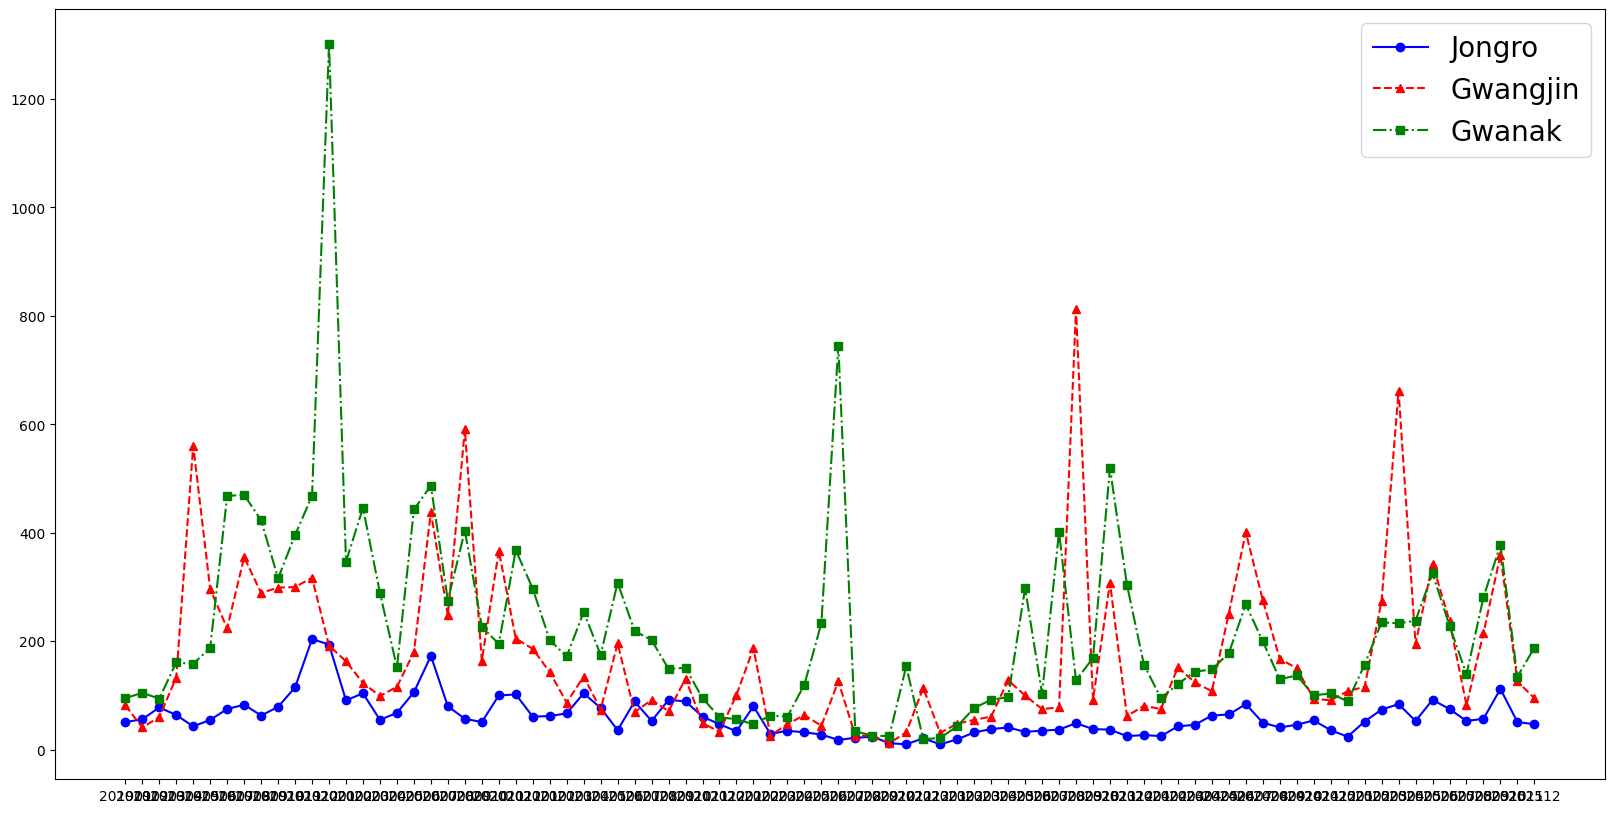

In [9]:
import matplotlib.pyplot as plt
df01 = df[df['지역']=='종로구']
df02 = df[df['지역']=='광진구']
df03 = df[df['지역']=='관악구']

plt.figure(figsize=(20, 10))
plt.plot(df01['날짜'], df01['거래건수'], color='b', marker='o',
         linestyle='-', label='Jongro')
plt.plot(df02['날짜'], df02['거래건수'], color='r', marker='^',
         linestyle='--', label='Gwangjin')
plt.plot(df03['날짜'], df03['거래건수'], color='g', marker='s',
         linestyle='-.', label='Gwanak')

plt.legend(fontsize=20)
plt.show()

In [28]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import os
from dotenv import load_dotenv
import pymysql
import time
import requests

load_dotenv()

# --- 1. 빈 값/에러를 막아주는 안전망 함수 ---
def safe_float(val):
    if not val:  # 값이 아예 없으면 None 반환
        return None
    # 쉼표, % 기호, 공백 제거
    val = str(val).replace(',', '').replace('%', '').strip()
    # 에프앤가이드 특유의 빈칸 기호들 처리
    if val in ['', '-', 'N/A']:
        return None
    try:
        return float(val)
    except ValueError:
        return None

def safe_int(val):
    if not val:
        return None
    val = str(val).replace(',', '').strip()
    if val in ['', '-', 'N/A']:
        return None
    try:
        return int(val)
    except ValueError:
        return None
# ---------------------------------------------

def stock_crawling(item):
    url = "https://comp.fnguide.com/SVO2/ASP/SVD_main.asp?pGB=1&gicode=A"+item+"&cID=&MenuYn=Y&ReportGB=&NewMenuID=11&stkGb=&strResearchYN="
    resp = urlopen(url)
    raw = resp.read()

    html = raw.decode('utf-8', errors='replace')
    bs_obj = BeautifulSoup(html, "html.parser")

    # 날짜
    date1 = bs_obj.find("span", {"class":"date"})
    date = date1.text.replace('[','').replace(']','').replace('/','-') if date1 else None

    # 기업 정보 & 종목 코드
    corp_name = bs_obj.find("h1", {"id":"giName"}).text
    code = bs_obj.find("div", {"class": "corp_group1"}).find("h2").text

    # 🛡️ 2. 데이터 추출 시 안전망 함수 적용
    stock_price = safe_int(bs_obj.find("span", {"id":"svdMainChartTxt11"}).text)
    fgn_own_ratio = safe_float(bs_obj.find("span", {"id":"svdMainChartTxt12"}).text)
    rel_return = safe_float(bs_obj.find("span", {"id":"svdMainChartTxt13"}).text)

    # 상단 테이블
    up_list = bs_obj.find("div", {"class":"corp_group2"})
    dd = up_list.find_all("dd")

    per = safe_float(dd[1].text)
    per_12m = safe_float(dd[3].text)
    per_ind = safe_float(dd[5].text)
    pbr = safe_float(dd[7].text)
    div_yid = safe_float(dd[9].text)

    # 시세현황 테이블
    table1 = bs_obj.find("div",{"id":"div1"})
    table2 = table1.find_all("td")
    
    volume = safe_int(table2[1].text)
    trans_price = safe_int(table2[3].text)
    mk_cpt_pfr = safe_int(table2[6].text)
    mk_cpt_cm = safe_int(table2[8].text)

    res = [date, corp_name, code, stock_price, fgn_own_ratio, rel_return,
           per, per_12m, per_ind, pbr, div_yid, volume, trans_price, mk_cpt_pfr, mk_cpt_cm]
    
    return res

def db_insert(res):
    conn = None  # DB 연결 초기화
    channel = "#stock_alarm01"
    
    db_pw = os.getenv('DB_PASSWORD')
    slack_token = os.getenv('SLACK_TOKEN')
    channel = "#stock_alarm01"

    try:
        conn = pymysql.connect(host='localhost', user='root', password=db_pw, db='stock', charset='utf8')
        db = conn.cursor()
        

        sql_state = """
            INSERT INTO stock.daily_market(
                dt, item_name, item_code, price, foreign_ownership_ratio, rel_return,
                per, per_12m, per_ind, pbr, dividend_yield, volume, trans_price, market_capital_prefer, market_capital_common
            ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        
        # 튜플 형태로 데이터를 통째로 넘김
        db.execute(sql_state, tuple(res))
        conn.commit()
        
        text = f"{res[0]}일 {res[1]} 주식정보 수집완료!"
        requests.post("https://slack.com/api/chat.postMessage",
                      headers={"Authorization": f"Bearer {slack_token}"},
                      data={"channel": channel, "text": text})

    except Exception as e:
        print(f"DB 저장 중 에러: {e}")
        text = "Check your stock crawler. (DB Insert Error)"
        requests.post("https://slack.com/api/chat.postMessage",
                      headers={"Authorization": f"Bearer {slack_token}"},
                      data={"channel": channel, "text": text})
        
    finally:
        # DB 연결이 생성된 경우에만 닫도록 안전하게 처리
        if conn is not None:
            conn.close()

if __name__ == '__main__':
    item_list = ['005930','088350','259960']

    for item in item_list:
        try:
            res = stock_crawling(item) 
            db_insert(res)
            print(f"{item} 수집 완료")
        except Exception as e:
            print(f"{item} 크롤링 중 에러 발생: {e}")
            
        time.sleep(3)

005930 수집 완료
088350 수집 완료
259960 수집 완료


In [ ]:
import pymysql

conn = pymysql.connect(host='localhost', user='root',
                       password='',db='stock',charset='utf8')

sql_state = """SELECT * FROM stock.daily_market WHERE dt BETWEEN
'2026-02-20' AND '2026-02-25';"""

In [5]:
db = conn.cursor()
db.execute(sql_state)
rows = db.fetchall()
conn.close()

In [6]:
print(rows)

((43, datetime.date(2026, 2, 20), '삼성전자', '005930', 190100, 51.09, 225.51, 28.96, 9.07, 40.54, 2.97, 0.88, 24213880, 45910, 12355613, 11253232), (44, datetime.date(2026, 2, 20), '한화생명', '088350', 6600, 7.45, 143.09, 7.78, None, 12.15, 0.45, None, 92055536, 5759, 57323, 57323), (45, datetime.date(2026, 2, 20), '크래프톤', '259960', 260500, 42.1, -21.54, 9.59, 12.1, 25.63, 1.81, None, 102902, 269, 123487, 123487), (46, datetime.date(2026, 2, 23), '삼성전자', '005930', 193000, 51.0, 231.62, 29.4, 9.03, 40.76, 3.02, 0.86, 26364684, 51077, 12535443, 11424901), (47, datetime.date(2026, 2, 23), '한화생명', '088350', 5970, 6.74, 127.86, 7.03, None, 12.21, 0.41, None, 110984121, 7222, 51851, 51851), (48, datetime.date(2026, 2, 23), '크래프톤', '259960', 259500, 42.1, -20.76, 9.55, 12.05, 25.87, 1.8, None, 100031, 260, 123013, 123013), (49, datetime.date(2026, 2, 24), '삼성전자', '005930', 200000, 50.96, 249.04, 30.47, 8.85, 42.47, 3.13, 0.83, 28060617, 55381, 12988984, 11839276), (50, datetime.date(2026, 2, 24), '

In [4]:
import pandas as pd

In [7]:
colnames = ['seq',
 'dt',
 'item_name',
 'item_code',
 'price',
 'foreign_ownership_ratio',
 'rel_return',
 'per',
 'per_12m',
 'per_ind',
 'pbr',
 'dividend_yield',
 'volume',
 'trans_price',
 'market_capital_prefer',
 'market_capital_common']

In [8]:
df = pd.DataFrame(rows, columns=colnames)

In [9]:
df

,seq,dt,item_name,item_code,price,foreign_ownership_ratio,rel_return,per,per_12m,per_ind,pbr,dividend_yield,volume,trans_price,market_capital_prefer,market_capital_common
0,43,2026-02-20,삼성전자,005930,190100,51.09,225.51,28.96,9.07,40.54,2.97,0.88,24213880,45910,12355613,11253232
1,44,2026-02-20,한화생명,088350,6600,7.45,143.09,7.78,NaN,12.15,0.45,NaN,92055536,5759,57323,57323
2,45,2026-02-20,크래프톤,259960,260500,42.10,-21.54,9.59,12.10,25.63,1.81,NaN,102902,269,123487,123487
3,46,2026-02-23,삼성전자,005930,193000,51.00,231.62,29.40,9.03,40.76,3.02,0.86,26364684,51077,12535443,11424901
4,47,2026-02-23,한화생명,088350,5970,6.74,127.86,7.03,NaN,12.21,0.41,NaN,110984121,7222,51851,51851
5,48,2026-02-23,크래프톤,259960,259500,42.10,-20.76,9.55,12.05,25.87,1.80,NaN,100031,260,123013,123013
6,49,2026-02-24,삼성전자,005930,200000,50.96,249.04,30.47,8.85,42.47,3.13,0.83,28060617,55381,12988984,11839276
7,50,2026-02-24,한화생명,088350,5320,6.45,105.41,6.27,NaN,11.79,0.36,NaN,36188330,1963,46206,46206
8,51,2026-02-24,크래프톤,259960,265000,42.04,-18.96,9.76,12.31,25.81,1.84,NaN,157071,416,125620,125620
9,52,2026-02-25,삼성전자,005930,203500,50.80,255.77,31.00,9.00,43.17,3.18,0.82,26987996,54742,13207595,12046463


In [10]:
df_sam = df[df['item_name']=='삼성전자']

(array([20504., 20505., 20506., 20507., 20508., 20509.]),
 [Text(20504.0, 0, '2026-02-20'),
  Text(20505.0, 0, '2026-02-21'),
  Text(20506.0, 0, '2026-02-22'),
  Text(20507.0, 0, '2026-02-23'),
  Text(20508.0, 0, '2026-02-24'),
  Text(20509.0, 0, '2026-02-25')])

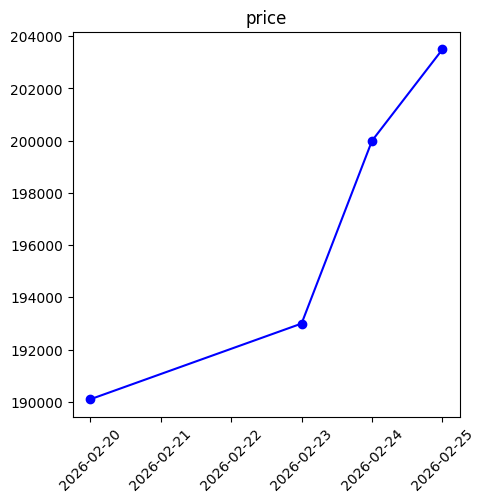

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.plot(df_sam['dt'], df_sam['price'], color='blue', marker='o', linestyle='-')
plt.title('price')
plt.xticks(rotation=45)

In [27]:
pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
